In [3]:
# 从theo.ipynb 删减得到，精简完整实验版本

import numpy as np
import math
import scipy.io
import matplotlib.pyplot as plt

import time
import mujoco
import mujoco.viewer
import random
import mediapy as media
import datetime
import os
import pandas as pd
import itertools
from tqdm import tqdm
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
import scipy
import ipywidgets as widgets
from IPython.display import display
from scipy.optimize import differential_evolution
import cv2
from pathlib import Path

# 获取项目根目录（从 notebooks/ 向上）
ROOT_DIR = Path.cwd().parent.parent.parent
print(f"Root directory: {ROOT_DIR}")

python(55788) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55789) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Root directory: /Users/flypig/Documents/Coding/MujocoLearn


In [2]:
# theta->static force (theoretical)
def get_static_func(theta_1, theta_2, k_3=637.52/2, k_4=631.6/2, l_10=0.174, l_20=0.252, m_3 = 0.18648, m_4=0.27266):
    """
        计算静力学
        - theta_1: 关节1角度
        - theta_2: 关节2角度
        - k_3: spring 1 stiffness
        - k_4: spring 2 stiffness
        - l_10: spring 1 original length
        - l_20: spring 2 original length
    """

    a_1 = 0.25
    a_2 = 0.25
    b_1 = 0.21213
    b_2 = 0.1
    d_1 = 0.06
    d_2 = 0.10
    s = 0

    M = 0.155  # 真实值
    m_1, m_2 = 0.086, 0.1033
    I_1, I_2 = (1/12 * m_1 * 0.25**2), (1/12 * m_2 * 0.25**2)

    # m_3, m_4 = 0.18648, 0.27266

    # 刚度参数
    # k_3, k_4 = 300/2, 300/2
    # k_3, k_4 = 637.52/2, 631.6/2

    # 阻尼参数
    c_3, c_4 = 22.68/2, 21.8/2

    # 重力加速度
    g = 9.8

    # 角度参数 (度转弧度)
    beta_1 = 8.13 / 180 * np.pi
    beta_2 = 30 / 180 * np.pi

    # 长度参数
    # l_10 = 0.174
    # l_20 = 0.252

    A_x_O = d_1
    A_y_O = 0

    B_x_O = -d_2
    B_y_O = 0

    C_x_O = b_1 * np.cos(theta_1 - beta_1)
    C_y_O = b_1 * np.sin(theta_1 - beta_1)

    D_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)
    D_y_O = a_1 * np.sin(theta_1) + b_2 * np.sin(theta_1 + theta_2 + beta_2)

    E_x_O = a_1 * np.cos(theta_1)
    E_y_O = a_1 * np.sin(theta_1)

    F_x_O = a_1 * np.cos(theta_1) + a_2 * np.cos(theta_1 + theta_2)
    F_y_O = a_1 * np.sin(theta_1) + a_2 * np.sin(theta_1 + theta_2)

    G_x_O = b_1 * np.cos(beta_1) * np.cos(theta_1)
    G_y_O = b_1 * np.cos(beta_1) * np.sin(theta_1)

    H_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(beta_2) * np.cos(theta_1 + theta_2)
    H_y_O = a_1 * np.sin(theta_1) + b_2 * np.cos(beta_2) * np.sin(theta_1 + theta_2)

    # 计算偏导数
    # 对 theta_1 的偏导数

    dA_x_O_dtheta_1 = 0
    dA_y_O_dtheta_1 = 0

    dB_x_O_dtheta_1 = 0
    dB_y_O_dtheta_1 = 0

    dC_x_O_dtheta_1 = -b_1 * np.sin(theta_1 - beta_1)
    dC_y_O_dtheta_1 = b_1 * np.cos(theta_1 - beta_1)

    dD_x_O_dtheta_1 = -a_1 * np.sin(theta_1) - b_2 * np.sin(theta_1 + theta_2 + beta_2)
    dD_y_O_dtheta_1 = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)

    dE_x_O_dtheta_1 = -a_1 * np.sin(theta_1)
    dE_y_O_dtheta_1 = a_1 * np.cos(theta_1)

    dF_x_O_dtheta_1 = -a_1 * np.sin(theta_1) - a_2 * np.sin(theta_1 + theta_2)
    dF_y_O_dtheta_1 = a_1 * np.cos(theta_1) + a_2 * np.cos(theta_1 + theta_2)

    dG_x_O_dtheta_1 = -b_1 * np.cos(beta_1) * np.sin(theta_1)
    dG_y_O_dtheta_1 = b_1 * np.cos(beta_1) * np.cos(theta_1)

    dH_x_O_dtheta_1 = -a_1 * np.sin(theta_1) - b_2 * np.cos(beta_2) * np.sin(theta_1 + theta_2)
    dH_y_O_dtheta_1 = a_1 * np.cos(theta_1) + b_2 * np.cos(beta_2) * np.cos(theta_1 + theta_2)

    # 对 theta_2 的偏导数

    dA_x_O_dtheta_2 = 0
    dA_y_O_dtheta_2 = 0

    dB_x_O_dtheta_2 = 0
    dB_y_O_dtheta_2 = 0

    dC_x_O_dtheta_2 = 0
    dC_y_O_dtheta_2 = 0

    dD_x_O_dtheta_2 = -b_2 * np.sin(theta_1 + theta_2 + beta_2)
    dD_y_O_dtheta_2 = b_2 * np.cos(theta_1 + theta_2 + beta_2)

    dE_x_O_dtheta_2 = 0
    dE_y_O_dtheta_2 = 0

    dF_x_O_dtheta_2 = -a_2 * np.sin(theta_1 + theta_2)
    dF_y_O_dtheta_2 = a_2 * np.cos(theta_1 + theta_2)

    dH_x_O_dtheta_2 = -b_2 * np.cos(beta_2) * np.sin(theta_1 + theta_2)
    dH_y_O_dtheta_2 = b_2 * np.cos(beta_2) * np.cos(theta_1 + theta_2)


    # 计算长度 l1 和 l2
    l_1 = np.sqrt((A_x_O - C_x_O)**2 + (A_y_O - C_y_O)**2)
    l_2 = np.sqrt((B_x_O - D_x_O)**2 + (B_y_O - D_y_O)**2)

    # 计算偏导数
    # 偏导数 d/dtheta_1
    dl_1_dtheta_1 = 1/l_1 * ((A_x_O - C_x_O) * (dA_x_O_dtheta_1 - dC_x_O_dtheta_1) + (A_y_O - C_y_O) * (dA_y_O_dtheta_1 - dC_y_O_dtheta_1))
    dl_2_dtheta_1 = 1/l_2 * ((B_x_O - D_x_O) * (dB_x_O_dtheta_1 - dD_x_O_dtheta_1) + (B_y_O - D_y_O) * (dB_y_O_dtheta_1 - dD_y_O_dtheta_1))

    # 偏导数 d/dtheta_2
    dl_1_dtheta_2 = 1/l_1 * ((A_x_O - C_x_O) * (dA_x_O_dtheta_2 - dC_x_O_dtheta_2) + (A_y_O - C_y_O) * (dA_y_O_dtheta_2 - dC_y_O_dtheta_2))
    dl_2_dtheta_2 = 1/l_2 * ((B_x_O - D_x_O) * (dB_x_O_dtheta_2 - dD_x_O_dtheta_2) + (B_y_O - D_y_O) * (dB_y_O_dtheta_2 - dD_y_O_dtheta_2))

    # print(dl_1_dtheta_2)  # check the model

    # 等式右侧
    RHSb_1 = -( m_1*g*(dE_y_O_dtheta_1/2) + m_2*g*((dE_y_O_dtheta_1+dF_y_O_dtheta_1)/2) + m_3*g*(dC_y_O_dtheta_1/2) + m_4*g*(dD_y_O_dtheta_1/2) )
    RHSb_2 = -( m_1*g*(dE_y_O_dtheta_2/2) + m_2*g*((dE_y_O_dtheta_2+dF_y_O_dtheta_2)/2) + m_3*g*(dC_y_O_dtheta_2/2) + m_4*g*(dD_y_O_dtheta_2/2) )
    b = np.array([RHSb_1, RHSb_2])

    # 等式左侧
    LHSA = np.array([[dl_1_dtheta_1, dl_2_dtheta_1], 
                    [dl_1_dtheta_2, dl_2_dtheta_2]])

    # 回复力
    F_k = np.array([k_3*(l_1-l_10), k_4*(l_2-l_20)])

    # 计算静力学
    StaticForce = np.linalg.solve(LHSA, b) + F_k
    return StaticForce

get_static_func(math.pi/6, math.pi/2*0, 637.52/2, 631.6/2, 0.174, 0.252)

array([-31.07359493,  57.5943789 ])

In [3]:
# Copy from <dynamic_identify.ipynb>
# Tools: 计算长度偏置（初始长度-原长）
def l_calulator(theta_1, theta_2):
    a_1 = 0.25
    a_2 = 0.25
    b_1 = 0.21213
    b_2 = 0.1
    d_1 = 0.06
    d_2 = 0.10

    # 角度参数 (度转弧度)
    beta_1 = 8.13 / 180 * np.pi
    beta_2 = 30 / 180 * np.pi

    A_x_O = d_1
    A_y_O = 0

    B_x_O = -d_2
    B_y_O = 0

    C_x_O = b_1 * np.cos(theta_1 - beta_1)
    C_y_O = b_1 * np.sin(theta_1 - beta_1)

    D_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)
    D_y_O = a_1 * np.sin(theta_1) + b_2 * np.sin(theta_1 + theta_2 + beta_2)

    # 计算长度 l1 和 l2
    l_1 = np.sqrt((A_x_O - C_x_O)**2 + (A_y_O - C_y_O)**2)
    l_2 = np.sqrt((B_x_O - D_x_O)**2 + (B_y_O - D_y_O)**2)

    return l_1, l_2

# Tools: 计算驱动器设置初始偏置，这里采用真实模型
def bias_calculator(l_10, l_20):
  l_1, l_2 = l_calulator(math.pi/2, math.pi/2)      # 真实模型
  l1_rel = l_10 - l_1
  l2_rel = l_20 - l_2
  return l1_rel/2, l2_rel/2

In [47]:
# theta->static force (Mujoco model)

# load the model
path = (ROOT_DIR / "models/v2_4/urdf/dog2_4singleLeg.xml").as_posix()    # 转换为标准路径格式
# path = (ROOT_DIR / "models/SingleLeg_ideal.xml").as_posix()    # 转换为标准路径格式
print(f"File path: {path}")

m = mujoco.MjModel.from_xml_path(path)
d = mujoco.MjData(m)

RB_BAA_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_SlideJoint")
RB_BAA_FM_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_FM_SlideJoint")
RB_MAA_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_SlideJoint")
RB_MAA_FM_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_FM_SlideJoint")
RB_Shoulder_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_Shoulder")
RB_Elbow_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_Elbow")

print(f"RB_BAA_SlideJoint_id: {RB_BAA_SlideJoint_id}")
print(f"RB_BAA_FM_SlideJoint_id: {RB_BAA_FM_SlideJoint_id}")
print(f"RB_MAA_SlideJoint_id: {RB_MAA_SlideJoint_id}")
print(f"RB_MAA_FM_SlideJoint_id: {RB_MAA_FM_SlideJoint_id}")
print(f"RB_Shoulder_id: {RB_Shoulder_id}")
print(f"RB_Elbow_id: {RB_Elbow_id}")


# NOTE: 注意这里是双层 try and else ~
def run_single_experiment(F1, F2, params):
    """
        单次实验运行函数
        :param params: 包含(stiffness_MAA, stiffness_BAA, l10, l20, damping_MAA, damping_BAA)的元组
    """
    try:
        stiffness_MAA, stiffness_BAA, l10, l20, damping_MAA, damping_BAA = params
        ForcePulse = np.array([F1, F2])
        
        m = mujoco.MjModel.from_xml_path(path)
        d = mujoco.MjData(m)

        # 设置刚度和阻尼
        for joint_id, stiffness, damping in zip(
            [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
            [stiffness_BAA, stiffness_BAA, stiffness_MAA, stiffness_MAA],
            [damping_BAA, damping_BAA, damping_MAA, damping_MAA]
        ):
            m.jnt_stiffness[joint_id] = stiffness * 2
            m.dof_damping[joint_id] = damping * 2

        MAA_bias, BAA_bias = bias_calculator(l10, l20)
        for joint_id, bias in zip(
            [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
            [BAA_bias, BAA_bias, MAA_bias, MAA_bias]
        ):
            m.qpos_spring[joint_id] = bias

        # m.dof_damping[RB_shoulder_id] = c1_thigh
        # m.dof_damping[RB_Elbow_id] = c2_calf

        d.ctrl = np.zeros_like(d.ctrl)
        mujoco.mj_step(m, d)

        # Experiment Settings
        ExpResultList = []
        time_exp = 20
        time_step = 19      # 稳定时间
        record = True
        valid = True

        start = d.time
        try:
            while (d.time - start) < time_exp:  # viewer.is_running() and
                elapsed_time = d.time - start
                # check validation
                if (math.pi/6 > (d.qpos[0]+math.pi/2)) or ((d.qpos[0]+math.pi/2) > math.pi*2/3):
                    # print("Invalid: theta_1 out of range")
                    valid = False
                    return None, None, valid
                if (0 > (d.qpos[1]+math.pi/2)) or ((d.qpos[1]+math.pi/2) > math.pi/2):
                    # print("Invalid: theta_2 out of range")
                    valid = False
                    return None, None, valid
                if 0 < elapsed_time < time_step:  # 稳定时间
                    d.ctrl[:2] = ForcePulse[0]
                    d.ctrl[2:] = ForcePulse[1]
                elif time_step <= elapsed_time < time_exp:  # 稳定时间
                    # d.ctrl[:] = 0  # 同时将所有控制信号置为0
                    
                    # Trick: 由于实际数据稳定，所以这里只记录10s后的模拟数据，如果开始不收敛一定10s后的误差也很大
                    if record:
                        Position = np.array(d.qpos)
                        # res = np.hstack((d.time, Position))
                        # ExpResultList.append(Position)
                        record = False
                    else:
                        pass
                mujoco.mj_step(m, d)  # update!

        # # 按住ctrl C退出循环
        except KeyboardInterrupt:
            return
        
        # data process
        # result_array = np.array(ExpResultList)
        # time_sim = result_array[:,0]-time_step
        theta1_sim = (Position[0]+math.pi/2)
        theta2_sim = (Position[1]+math.pi/2)
        return theta1_sim, theta2_sim, valid    # 增加是否有效的返回值
    
    except Exception as e:
        print(f"Error: {e}")
        raise e

File path: /Users/flypig/Documents/Coding/MujocoLearn/models/v2_4/urdf/dog2_4singleLeg.xml
RB_BAA_SlideJoint_id: 6
RB_BAA_FM_SlideJoint_id: 7
RB_MAA_SlideJoint_id: 3
RB_MAA_FM_SlideJoint_id: 4
RB_Shoulder_id: 0
RB_Elbow_id: 1


In [50]:
run_single_experiment(
    F1=0,
    F2=0,
    params=(637.52/2, 631.6/2, 0.174, 0.252, 22.68/2, 21.8/2)
)

(np.float64(1.2210296863931547), np.float64(1.2914696407680781), True)

In [51]:
# 运行实验

def run_experiment(k3=637.52/2, k4=631.6/2, l10=0.174, l20=0.252):
    '''
        运行实验
        - k3: spring 1 stiffness
        - k4: spring 2 stiffness
        - l10: spring 1 original length
        - l20: spring 2 original length"
        - return : exp_data-dict of [theta_1_theo, theta_2_theo, theta_1_sim, theta_2_sim, F1_apply, F2_apply]
    '''
    theta_1_tar_array = np.linspace(math.pi/6, math.pi*2/3, 20)
    theta_2_tar_array = np.linspace(0, math.pi/2, 20)
    exp_data = []

    for i in tqdm(range(len(theta_1_tar_array))):
        for j in range(len(theta_2_tar_array)):
            theta_1_theo = theta_1_tar_array[i]
            theta_2_theo = theta_2_tar_array[j]

            force_theoretical = get_static_func(theta_1_theo, theta_2_theo, k3, k4, l10, l20)
            theta_1, theta_2, valid = run_single_experiment(*force_theoretical, (k3, k4, l10, l20, 22.68/2, 21.8/2))

            if valid:
                # record the data
                exp_data.append({
                    "theta_1_theo": theta_1_theo,
                    "theta_2_theo": theta_2_theo,
                    "theta_1_sim": theta_1,
                    "theta_2_sim": theta_2,
                    "F1_apply": force_theoretical[0],
                    "F2_apply": force_theoretical[1],
                })
    valid_exp_num = len(exp_data)
    exp_data = pd.DataFrame(data=exp_data)
    return exp_data, valid_exp_num

In [52]:
# 多组实验-随机采样
mid = np.array([637.52/2, 631.6/2, 0.174, 0.252])
lower = mid*np.array([0.5, 0.5, 0.8, 0.8])
upper = mid*np.array([1.5, 1.5, 1.2, 1.2])
n = 100
# np.random.seed(123)
parameter_set = np.random.uniform(lower, upper, size=(n, len(lower)))
parameter_set.shape

(100, 4)

In [53]:
multi_exp_data = []
theta_1_theo_tabel = []
theta_2_theo_tabel = []
theta_1_sim_tabel = []
theta_2_sim_tabel = []

for i in range(n):
    print(f"Experiment {i+1}:")
    exp_data, valid_exp_num = run_experiment(*parameter_set[i])
    if valid_exp_num == 0:
        print("No valid experiment data.")
        continue
    theta_1_theo_array = exp_data["theta_1_theo"].to_numpy()
    print(theta_1_theo_array.shape)
    theta_2_theo_array = exp_data["theta_2_theo"].to_numpy()
    theta_1_sim_array = exp_data["theta_1_sim"].to_numpy()
    theta_2_sim_array = exp_data["theta_2_sim"].to_numpy()
    # 计算 RMSE, MAE, MaxAE
    RMSE_theta_1 = np.sqrt(np.mean((theta_1_theo_array - theta_1_sim_array)**2))
    RMSE_theta_2 = np.sqrt(np.mean((theta_2_theo_array - theta_2_sim_array)**2))
    MAE_theta_1 = np.mean(np.abs(theta_1_theo_array - theta_1_sim_array))
    MAE_theta_2 = np.mean(np.abs(theta_2_theo_array - theta_2_sim_array))
    MaxAE_theta_1 = np.max(np.abs(theta_1_theo_array - theta_1_sim_array))
    MaxAE_theta_2 = np.max(np.abs(theta_2_theo_array - theta_2_sim_array))
    multi_exp_data.append({
        "k3": parameter_set[i][0],
        "k4": parameter_set[i][1],
        "l10": parameter_set[i][2],
        "l20": parameter_set[i][3],
        "RMSE_theta_1": RMSE_theta_1,
        "RMSE_theta_2": RMSE_theta_2,
        "MAE_theta_1": MAE_theta_1,
        "MAE_theta_2": MAE_theta_2,
        "MaxAE_theta_1": MaxAE_theta_1,
        "MaxAE_theta_2": MaxAE_theta_2,
        "valid_exp_num": valid_exp_num,
    })
    theta_1_theo_tabel.append(theta_1_theo_array)
    theta_2_theo_tabel.append(theta_2_theo_array)
    theta_1_sim_tabel.append(theta_1_sim_array)
    theta_2_sim_tabel.append(theta_2_sim_array)


Experiment 1:


100%|██████████| 20/20 [00:23<00:00,  1.16s/it]


(122,)
Experiment 2:


100%|██████████| 20/20 [00:25<00:00,  1.28s/it]


(131,)
Experiment 3:


...

(115,)
Experiment 99:


100%|██████████| 20/20 [00:25<00:00,  1.28s/it]


(120,)
Experiment 100:


100%|██████████| 20/20 [00:26<00:00,  1.30s/it]

(129,)


In [54]:
multi_exp_data = pd.DataFrame(data=multi_exp_data)
print(multi_exp_data)
# 保存为 CSV
time_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
multi_exp_data.to_csv(f"./exp_data/static_multiexp_{time_str}.csv", index=False)

            k3          k4       l10       l20  RMSE_theta_1  RMSE_theta_2  \
0   217.434895  281.354159  0.159269  0.268643      0.001097      0.005872   
1   226.087165  226.942952  0.196693  0.209628      0.001145      0.006934   
2   320.446285  161.388831  0.163819  0.212959      0.001040      0.008699   
3   196.060765  278.877441  0.194302  0.252466      0.001180      0.006023   
4   204.502405  217.562807  0.194433  0.228734      0.001212      0.007235   
..         ...         ...       ...       ...           ...           ...   
95  447.968864  447.717464  0.175503  0.209223      0.000640      0.003734   
96  426.936553  463.174691  0.152343  0.281306      0.000655      0.003672   
97  265.710113  327.041773  0.178083  0.250292      0.000956      0.005138   
98  170.140059  292.824174  0.150564  0.247665      0.001237      0.005877   
99  377.419278  237.817528  0.192862  0.280951      0.000830      0.006333   

    MAE_theta_1  MAE_theta_2  MaxAE_theta_1  MaxAE_theta_2  val

In [4]:
# load data: static_multiexp_20250323_193259.csv
multi_exp_data = pd.read_csv("./exp_data/static_multiexp_20250323_193259.csv")
# overall data
theta_1_RMSE = math.sqrt((multi_exp_data["RMSE_theta_1"]**2).mean())
theta_2_RMSE = math.sqrt((multi_exp_data["RMSE_theta_2"]**2).mean())
theta_1_MAE = multi_exp_data["MAE_theta_1"].mean()
theta_2_MAE = multi_exp_data["MAE_theta_2"].mean()
theta_1_MaxAE = multi_exp_data["MaxAE_theta_1"].max()
theta_2_MaxAE = multi_exp_data["MaxAE_theta_2"].max()
print(f"Overall RMSE theta_1: {theta_1_RMSE}, RMSE theta_2: {theta_2_RMSE}")
print(f"Overall MAE theta_1: {theta_1_MAE}, MAE theta_2: {theta_2_MAE}")
print(f"Overall MaxAE theta_1: {theta_1_MaxAE}, MaxAE theta_2: {theta_2_MaxAE}")


Overall RMSE theta_1: 0.0009386872425202674, RMSE theta_2: 0.005864764480538676
Overall MAE theta_1: 0.0007860619377870259, MAE theta_2: 0.005556879794031716
Overall MaxAE theta_1: 0.0037860325033696, MaxAE theta_2: 0.0155920196404594


IndexError: list index out of range

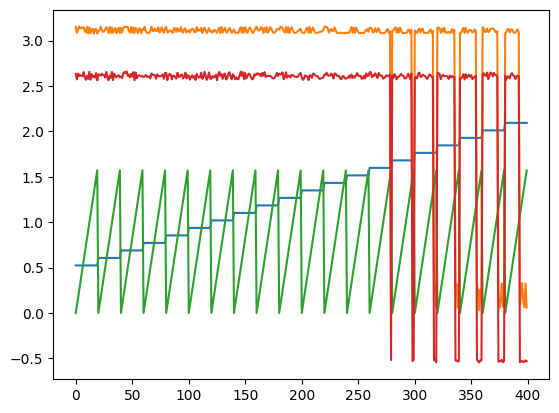

In [12]:
plt.plot(theta_1_theo_tabel[0], label="theta_1_theo")
plt.plot(theta_1_sim_tabel[0], label="theta_1_sim")
plt.plot(theta_2_theo_tabel[0], label="theta_2_theo")
plt.plot(theta_2_sim_tabel[0], label="theta_2_sim")

print(theta_1_theo_tabel[2]-theta_1_sim_tabel[2])
print(theta_2_theo_tabel[1]-theta_2_sim_tabel[1])


In [ ]:
# 单组实验
exp_data = run_experiment(637.52/2, 631.6/2, 0.174, 0.252)
print(exp_data)

# 保存为 CSV
time_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
exp_data.to_csv(f"./exp_data/static_{time_str}.csv", index=False)

In [ ]:
# 处理数据
theta_1_theo_array = exp_data["theta_1_theo"].to_numpy()
theta_2_theo_array = exp_data["theta_2_theo"].to_numpy()
theta_1_sim_array = exp_data["theta_1_sim"].to_numpy()
theta_2_sim_array = exp_data["theta_2_sim"].to_numpy()

In [ ]:
plt.plot(theta_1_theo_array-theta_1_sim_array, label="theta_1")
plt.plot(theta_2_theo_array-theta_2_sim_array, label="theta_2")
plt.xlabel("Sample")
plt.ylabel("Error")
plt.title("Error between theoretical and simulation")
plt.legend()


In [ ]:
# plot error of 2 mat
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Theta1_error")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.imshow((theta_1_theoretical-theta_1_sim), cmap='hot', interpolation='nearest')
plt.colorbar(label='Value')
plt.subplot(1, 2, 2)

plt.title("Theta2_error")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.imshow((theta_2_theoretical-theta_2_sim), cmap='hot', interpolation='nearest')
plt.colorbar(label='Value')



In [ ]:
# old version

theta_1_array = np.linspace(math.pi/6, math.pi*2/3, 20) # 切分十个点
theta_2_array = np.linspace(0, math.pi*1/2, 20)

# 创建一个值矩阵，用于存储每一对 (theta_1, theta_2) 的计算结果
F1_matrix = np.zeros((len(theta_1_array), len(theta_2_array)))
F2_matrix = np.zeros((len(theta_1_array), len(theta_2_array)))

# 使用双重循环计算每一对 (theta_1, theta_2) 对应的 f 值
for i, theta_1 in enumerate(theta_1_array):
    for j, theta_2 in enumerate(theta_2_array):
        StaticForce = get_static_func(theta_1, theta_2)
        F1_matrix[i, j] = StaticForce[0]
        F2_matrix[i, j] = StaticForce[1]

# 输出结果
print("生成的值矩阵：")
F1_Mat_data = {
    "F1_matrix": F1_matrix
}
F2_Mat_data = {
    "F2_matrix": F2_matrix
}
# 使用 scipy.io.savemat 保存 .mat 文件
scipy.io.savemat('F1_10.mat', F1_Mat_data)
scipy.io.savemat('F2_10.mat', F2_Mat_data)


In [ ]:
theta_1_array = np.linspace(math.pi/6, math.pi*2/3, 100) # 切分十个点
theta_2_array = np.linspace(0, math.pi*1/2, 100)

# F1_array = np.array((11, 11))
# F2_array = np.array((11, 11))

# 创建一个值矩阵，用于存储每一对 (theta_1, theta_2) 的计算结果
F1_matrix = np.zeros((len(theta_1_array), len(theta_2_array)))
F2_matrix = np.zeros((len(theta_1_array), len(theta_2_array)))

# 使用双重循环计算每一对 (theta_1, theta_2) 对应的 f 值
for i, theta_1 in enumerate(theta_1_array):
    for j, theta_2 in enumerate(theta_2_array):
        StaticForce = get_static_func(theta_1, theta_2)
        F1_matrix[i, j] = StaticForce[0]
        F2_matrix[i, j] = StaticForce[1]

# 输出结果
print("生成的值矩阵：")
F1_Mat_data = {
    "F1_matrix": F1_matrix
}
F2_Mat_data = {
    "F2_matrix": F2_matrix
}
# 使用 scipy.io.savemat 保存 .mat 文件
scipy.io.savemat('F1_100.mat', F1_Mat_data)
scipy.io.savemat('F2_100.mat', F2_Mat_data)

In [ ]:
# Matlab 动力学仿真的实验数据
F1_matlab = scipy.io.loadmat('F1matlab.mat').get("F1")
F2_matlab = scipy.io.loadmat('F2matlab.mat').get("F2")
F1_matlab = np.array(F1_matlab)   
F2_matlab = np.array(F2_matlab)
# 处理Mesh数据填写的区别: 都以Mesh的列优先为准
F1_matrix = F1_matrix.T
F2_matrix = F2_matrix.T


plt.figure()
plt.imshow(F1_matrix - F1_matlab, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.xlabel('theta_1')
plt.ylabel('theta_2')

plt.title('Error Heatmap of Theta1')
plt.xlabel('theta_1/rad')
plt.ylabel('theta_2/rad')

# 设置 x 和 y 轴刻度
plt.xticks(ticks=np.arange(F1_matrix.shape[1])[0::10], labels=[f'{round(i, 2)}' for i in theta_1_array[0::10]], rotation=90)
plt.yticks(ticks=np.arange(F1_matrix.shape[0])[0::10], labels=[f'{round(i, 2)}' for i in theta_2_array[0::10]])

plt.show()

plt.figure()
plt.imshow(F2_matrix - F2_matlab, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.xlabel('theta_1')
plt.ylabel('theta_2')

plt.title('Error Heatmap of Theta2')
plt.xlabel('theta_1/rad')
plt.ylabel('theta_2/rad')

# 设置 x 和 y 轴刻度
plt.xticks(ticks=np.arange(F2_matrix.shape[1])[0::10], labels=[f'{round(i, 2)}' for i in theta_1_array[0::10]], rotation=90)
plt.yticks(ticks=np.arange(F2_matrix.shape[0])[0::10], labels=[f'{round(i, 2)}' for i in theta_2_array[0::10]])

plt.show()



In [ ]:
# meshgridTest
x_test, y_test = np.meshgrid([1, 2, 3], [4, 5])
plt.imshow(x_test)